In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [96]:
df = pd.read_csv('Mall_Customers.csv')

In [97]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [79]:
customer_data.shape

(200, 5)

In [98]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [99]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [124]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [125]:
wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X_scaled)

  wcss.append(kmeans.inertia_)

C:\Users\Ajay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Ajay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Ajay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Ajay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\

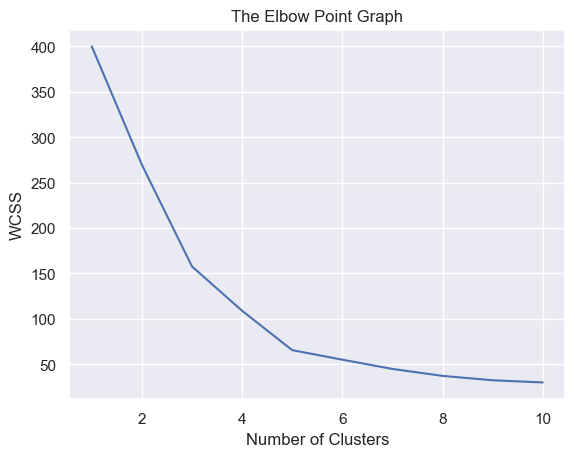

In [138]:
plt.plot(range(1,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [127]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)
Y = kmeans.fit_predict(X_scaled)
print(Y)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


C:\Users\Ajay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [128]:
df['Cluster'] = Y

In [129]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster_Label
0,1,Male,19,15,39,3,Low Income & Low Purchase
1,2,Male,21,15,81,4,Low Income & High Purchase
2,3,Female,20,16,6,3,Low Income & Low Purchase
3,4,Female,23,16,77,4,Low Income & High Purchase
4,5,Female,31,17,40,3,Low Income & Low Purchase


In [130]:
df['Cluster'].value_counts()

Cluster
0    81
1    39
2    35
3    23
4    22
Name: count, dtype: int64

In [131]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

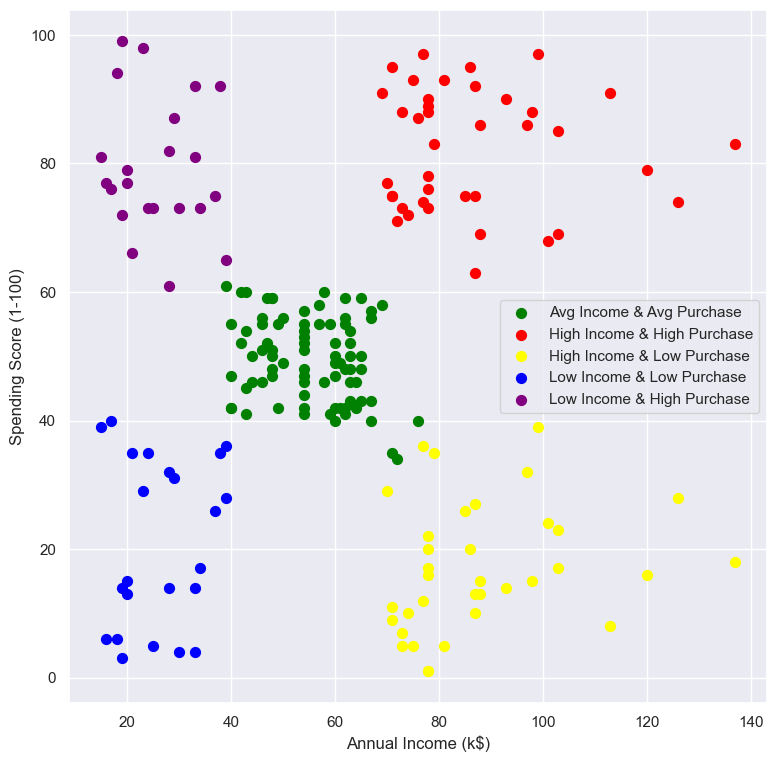

In [133]:
plt.figure(figsize=(9,9))

plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Avg Income & Avg Purchase')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label='High Income & High Purchase')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='yellow', label='High Income & Low Purchase')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='blue', label='Low Income & Low Purchase')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='purple', label='Low Income & High Purchase')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [134]:
cluster_map = {
    0: "Avg Income & Avg Purchase",
    1: "High Income & High Purchase",
    2: "High Income & Low Purchase",
    3: "Low Income & Low Purchase",
    4: "Low Income & High Purchase"
}

df['Cluster_Label'] = df['Cluster'].map(cluster_map)

In [135]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster_Label
0,1,Male,19,15,39,3,Low Income & Low Purchase
1,2,Male,21,15,81,4,Low Income & High Purchase
2,3,Female,20,16,6,3,Low Income & Low Purchase
3,4,Female,23,16,77,4,Low Income & High Purchase
4,5,Female,31,17,40,3,Low Income & Low Purchase
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,High Income & High Purchase
196,197,Female,45,126,28,2,High Income & Low Purchase
197,198,Male,32,126,74,1,High Income & High Purchase
198,199,Male,32,137,18,2,High Income & Low Purchase
